In [1]:
!pip install kagglehub -q

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, glob, zipfile
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

plt.rcParams.update({
    "figure.dpi"        : 130,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "grid.linestyle"    : "--",
    "font.size"         : 11,
})

SAVE_DIR    = "/content/car_price_plots"
CURRENT_YEAR = 2024
os.makedirs(SAVE_DIR, exist_ok=True)

print("✅ Libraries ready!")
print(f"📁 Plots will be saved to: {SAVE_DIR}")


✅ Libraries ready!
📁 Plots will be saved to: /content/car_price_plots


In [2]:
path = kagglehub.dataset_download("vijayaadithyanvg/car-price-predictionused-cars")
print(f"✅ Downloaded to: {path}")

csv_files = glob.glob(f"{path}/**/*.csv", recursive=True) + glob.glob(f"{path}/*.csv")
print("\n📄 CSV files found:")
for f in csv_files:
    print(f"   {f}")

DATASET_PATH = csv_files[0]
print(f"\n▶ Using: {DATASET_PATH}")


100%|██████████| 3.76k/3.76k [00:00<00:00, 3.05MB/s]

Extracting files...
✅ Downloaded to: /root/.cache/kagglehub/datasets/vijayaadithyanvg/car-price-predictionused-cars/versions/1

📄 CSV files found:
   /root/.cache/kagglehub/datasets/vijayaadithyanvg/car-price-predictionused-cars/versions/1/car data.csv
   /root/.cache/kagglehub/datasets/vijayaadithyanvg/car-price-predictionused-cars/versions/1/car data.csv

▶ Using: /root/.cache/kagglehub/datasets/vijayaadithyanvg/car-price-predictionused-cars/versions/1/car data.csv


## 3.  Load & Inspect Data

In [3]:
df = pd.read_csv(DATASET_PATH)
print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
display(df.head())


Shape  : (301, 9)
Columns: ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
print("Data Types:")
print(df.dtypes)
print(f"\nMissing Values:")
print(df.isnull().sum())
print(f"\nDuplicates: {df.duplicated().sum()}")


Data Types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Duplicates: 2


## 4.  Data Cleaning

In [5]:
# ── Standardise column names (handle minor variations) ─────────────────
col_map = {}
for c in df.columns:
    cl = c.strip().lower().replace(" ","_")
    col_map[c] = cl
df.rename(columns=col_map, inplace=True)

# Detect target column
TARGET = next((c for c in df.columns if "selling" in c.lower()), None)
if TARGET is None:
    TARGET = next((c for c in df.columns if "price" in c.lower()), df.columns[-1])
print(f"✅ Target column detected: '{TARGET}'")

# Drop rows where target is missing
df.dropna(subset=[TARGET], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Standardise key column names
rename_final = {}
for c in df.columns:
    if "year"         in c:  rename_final[c] = "Year"
    elif "km"         in c:  rename_final[c] = "Kms_Driven"
    elif "present"    in c:  rename_final[c] = "Present_Price"
    elif "fuel"       in c:  rename_final[c] = "Fuel_Type"
    elif "seller"     in c:  rename_final[c] = "Seller_Type"
    elif "transmis"   in c:  rename_final[c] = "Transmission"
    elif "owner"      in c:  rename_final[c] = "Owner"
    elif "car_name"   in c or "name" in c: rename_final[c] = "Car_Name"
    elif c == TARGET:        rename_final[c] = "Selling_Price"
df.rename(columns=rename_final, inplace=True)
TARGET = "Selling_Price"

# Remove outliers — Selling_Price
q99 = df[TARGET].quantile(0.99)
q01 = df[TARGET].quantile(0.01)
df  = df[(df[TARGET] >= q01) & (df[TARGET] <= q99)]

# Kms_Driven — remove extreme outliers
if "Kms_Driven" in df.columns:
    df = df[df["Kms_Driven"] < df["Kms_Driven"].quantile(0.99)]

print(f"✅ Cleaned shape: {df.shape}")
print(f"   Price range: ₹{df[TARGET].min():.2f}L — ₹{df[TARGET].max():.2f}L")
display(df.describe().round(2))


✅ Target column detected: 'selling_price'
✅ Cleaned shape: (290, 9)
   Price range: ₹0.16L — ₹23.00L


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,290.00,290.00,290.00,290.00,290.00
mean,2013.73,4.40,7.15,33850.69,0.04
std,2.79,4.24,6.63,24514.84,0.25
min,2003.00,0.16,0.32,500.00,0.00
25%,2012.00,0.96,1.42,15000.00,0.00
50%,2014.00,3.62,6.25,31213.50,0.00
75%,2016.00,5.99,9.50,46654.50,0.00
max,2018.00,23.00,35.96,142000.00,3.00


## 5.  Feature Engineering

In [6]:
# Car Age
if "Year" in df.columns:
    df["Car_Age"] = CURRENT_YEAR - df["Year"]

# Extract brand from Car_Name
if "Car_Name" in df.columns:
    df["Brand"] = df["Car_Name"].str.split().str[0].str.strip().str.title()
    # Normalize common brand names
    brand_fix = {
        "Maruti":"Maruti","Hyundai":"Hyundai","Honda":"Honda","Toyota":"Toyota",
        "Ford":"Ford","Chevrolet":"Chevrolet","Tata":"Tata","Mahindra":"Mahindra",
        "Volkswagen":"Volkswagen","Skoda":"Skoda","Renault":"Renault",
        "Nissan":"Nissan","Datsun":"Datsun","Jeep":"Jeep","Fiat":"Fiat",
        "Mercedes-Benz":"Mercedes","Bmw":"BMW","Audi":"Audi","Land":"Land Rover",
    }
    df["Brand"] = df["Brand"].replace(brand_fix)

    # Brand tier
    luxury  = ["BMW","Audi","Mercedes","Jaguar","Porsche","Land Rover","Volvo"]
    mid     = ["Honda","Toyota","Volkswagen","Skoda","Hyundai","Renault","Ford","Nissan"]
    df["Brand_Tier"] = df["Brand"].apply(
        lambda b: "Luxury" if b in luxury else ("Mid" if b in mid else "Budget"))

# Price per km (efficiency proxy)
if "Kms_Driven" in df.columns:
    df["Price_per_km"] = df[TARGET] / (df["Kms_Driven"] + 1)

print("✅ Feature engineering done!")
print(f"   New features: Car_Age, Brand, Brand_Tier, Price_per_km")
if "Brand" in df.columns:
    print(f"\n   Brand Tier Distribution:")
    print(df["Brand_Tier"].value_counts().to_string())


✅ Feature engineering done!
   New features: Car_Age, Brand, Brand_Tier, Price_per_km

   Brand Tier Distribution:
Brand_Tier
Budget    275
Mid        15


## 6.  EDA — Price Distribution & Brand Analysis

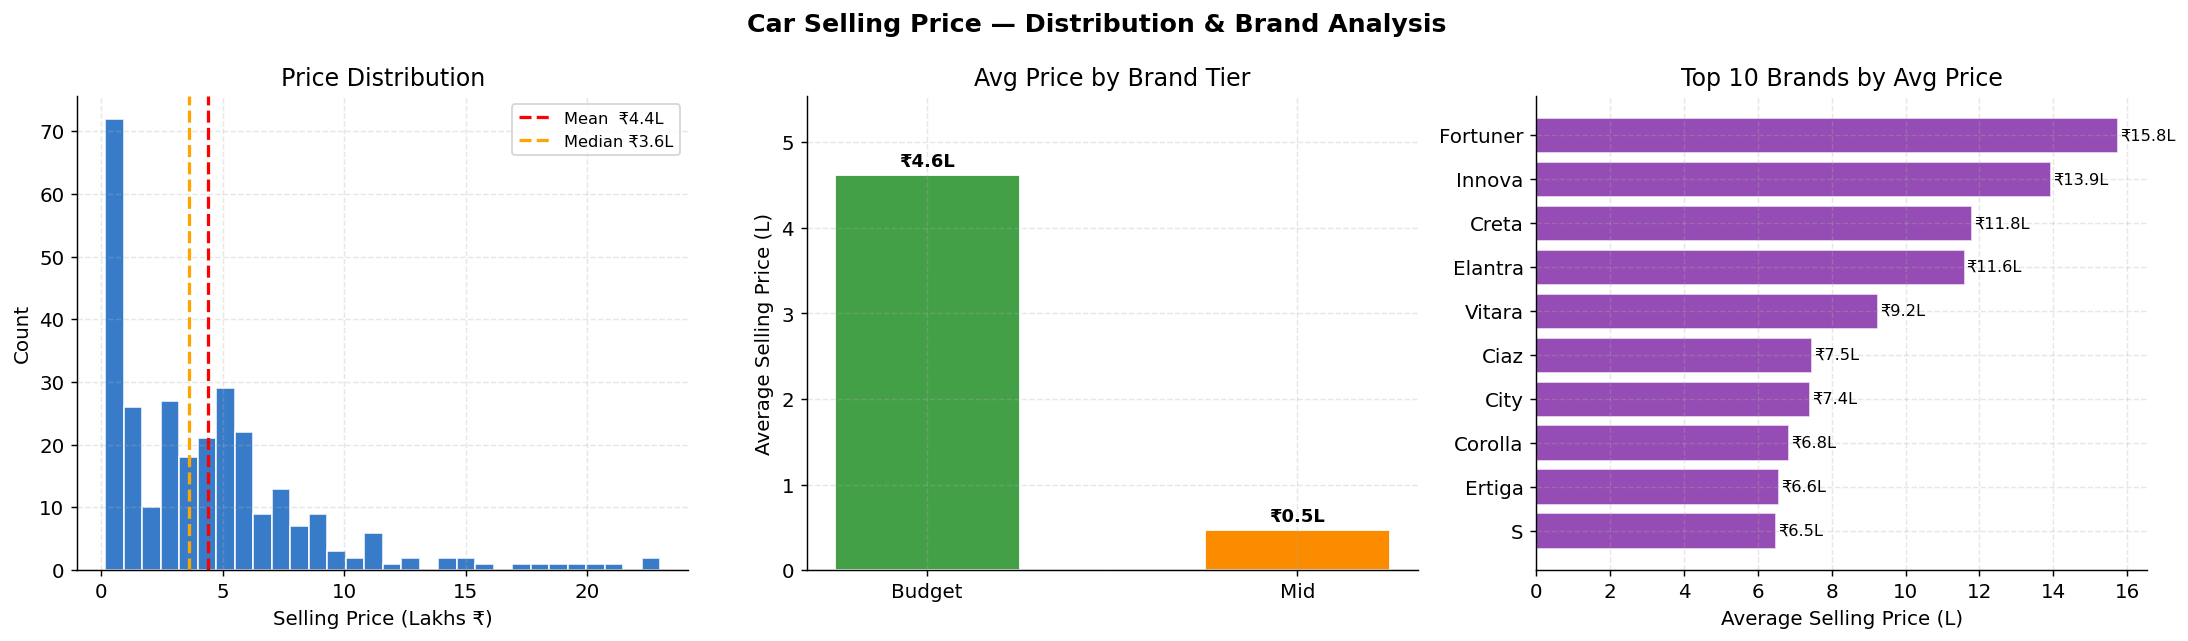

✅ Saved → /content/car_price_plots/fig1_price_distribution.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Car Selling Price — Distribution & Brand Analysis",
             fontsize=14, fontweight="bold")

# Histogram
ax1 = axes[0]
ax1.hist(df[TARGET], bins=30, color="#1565C0", alpha=0.85, edgecolor="white")
ax1.axvline(df[TARGET].mean(),   color="red",    linestyle="--", lw=1.8,
            label=f"Mean  ₹{df[TARGET].mean():.1f}L")
ax1.axvline(df[TARGET].median(), color="orange", linestyle="--", lw=1.8,
            label=f"Median ₹{df[TARGET].median():.1f}L")
ax1.set_xlabel("Selling Price (Lakhs ₹)")
ax1.set_ylabel("Count"); ax1.set_title("Price Distribution"); ax1.legend(fontsize=9)

# Brand tier avg price
ax2 = axes[1]
if "Brand_Tier" in df.columns:
    tier_means = df.groupby("Brand_Tier")[TARGET].mean().sort_values(ascending=False)
    tier_cols  = {"Luxury":"#E53935","Mid":"#FB8C00","Budget":"#43A047"}
    bars = ax2.bar(tier_means.index, tier_means.values,
                   color=[tier_cols.get(t,"gray") for t in tier_means.index],
                   edgecolor="white", width=0.5)
    for bar, val in zip(bars, tier_means.values):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f"₹{val:.1f}L", ha="center", fontsize=10, fontweight="bold")
    ax2.set_ylabel("Average Selling Price (L)"); ax2.set_title("Avg Price by Brand Tier")
    ax2.set_ylim(0, tier_means.max() * 1.2)

# Top 10 brands
ax3 = axes[2]
if "Brand" in df.columns:
    top_brands = (df.groupby("Brand")[TARGET].mean()
                    .sort_values(ascending=False).head(10))
    ax3.barh(top_brands.index[::-1], top_brands.values[::-1],
             color="#7B1FA2", alpha=0.8, edgecolor="white")
    for i, val in enumerate(top_brands.values[::-1]):
        ax3.text(val+0.05, i, f"₹{val:.1f}L", va="center", fontsize=9)
    ax3.set_xlabel("Average Selling Price (L)")
    ax3.set_title("Top 10 Brands by Avg Price")

plt.tight_layout()
SAVE1 = f"{SAVE_DIR}/fig1_price_distribution.png"
plt.savefig(SAVE1, bbox_inches="tight"); plt.show()
print(f"✅ Saved → {SAVE1}")


## 7.  EDA — Numeric Features vs Selling Price

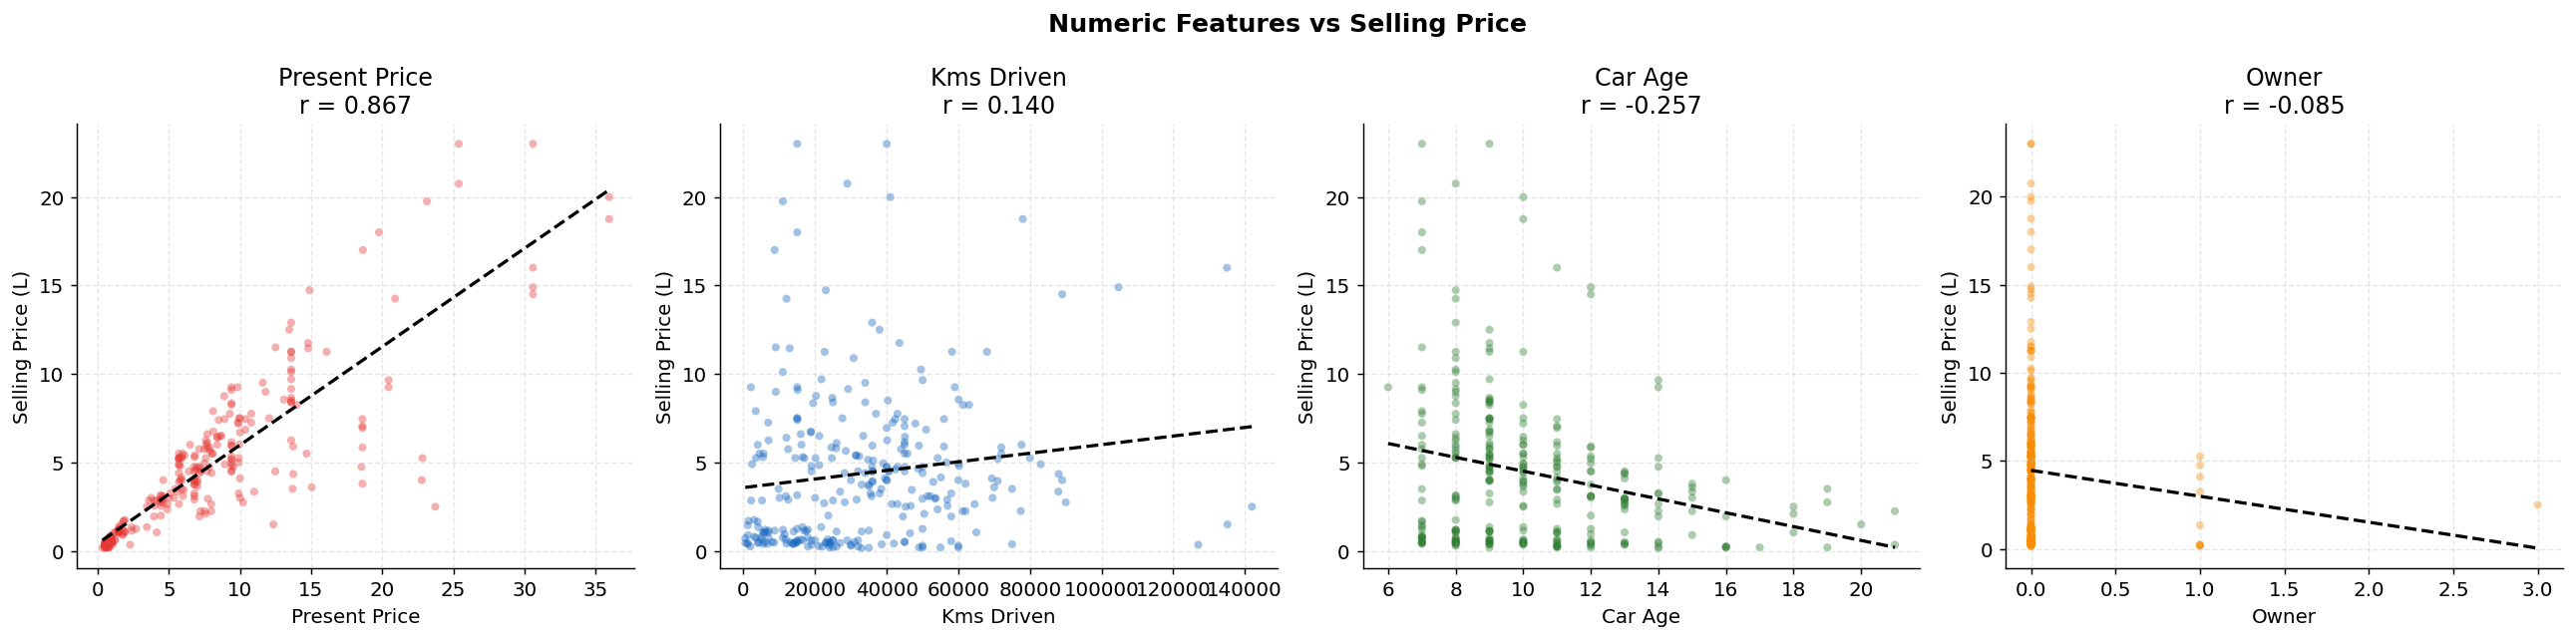

✅ Saved → /content/car_price_plots/fig2_feature_vs_price.png


In [8]:
num_features = [c for c in ["Present_Price","Kms_Driven","Car_Age","Owner"]
                if c in df.columns]
colors_f = ["#E53935","#1565C0","#2E7D32","#FB8C00"]

fig, axes = plt.subplots(1, len(num_features), figsize=(5*len(num_features), 5))
fig.suptitle("Numeric Features vs Selling Price", fontsize=14, fontweight="bold")
if len(num_features) == 1: axes = [axes]

for ax, feat, col in zip(axes, num_features, colors_f):
    ax.scatter(df[feat], df[TARGET], alpha=0.4, s=20, color=col, edgecolors="none")
    try:
        m, b = np.polyfit(df[feat].fillna(df[feat].median()), df[TARGET], 1)
        xs   = np.linspace(df[feat].min(), df[feat].max(), 100)
        ax.plot(xs, m*xs+b, color="black", linestyle="--", linewidth=1.8)
    except Exception:
        pass
    r = df[feat].corr(df[TARGET])
    ax.set_xlabel(feat.replace("_"," ")); ax.set_ylabel("Selling Price (L)")
    ax.set_title(f"{feat.replace('_',' ')}\nr = {r:.3f}")

plt.tight_layout()
SAVE2 = f"{SAVE_DIR}/fig2_feature_vs_price.png"
plt.savefig(SAVE2, bbox_inches="tight"); plt.show()
print(f"✅ Saved → {SAVE2}")


## 8.  EDA — Categorical Features vs Selling Price

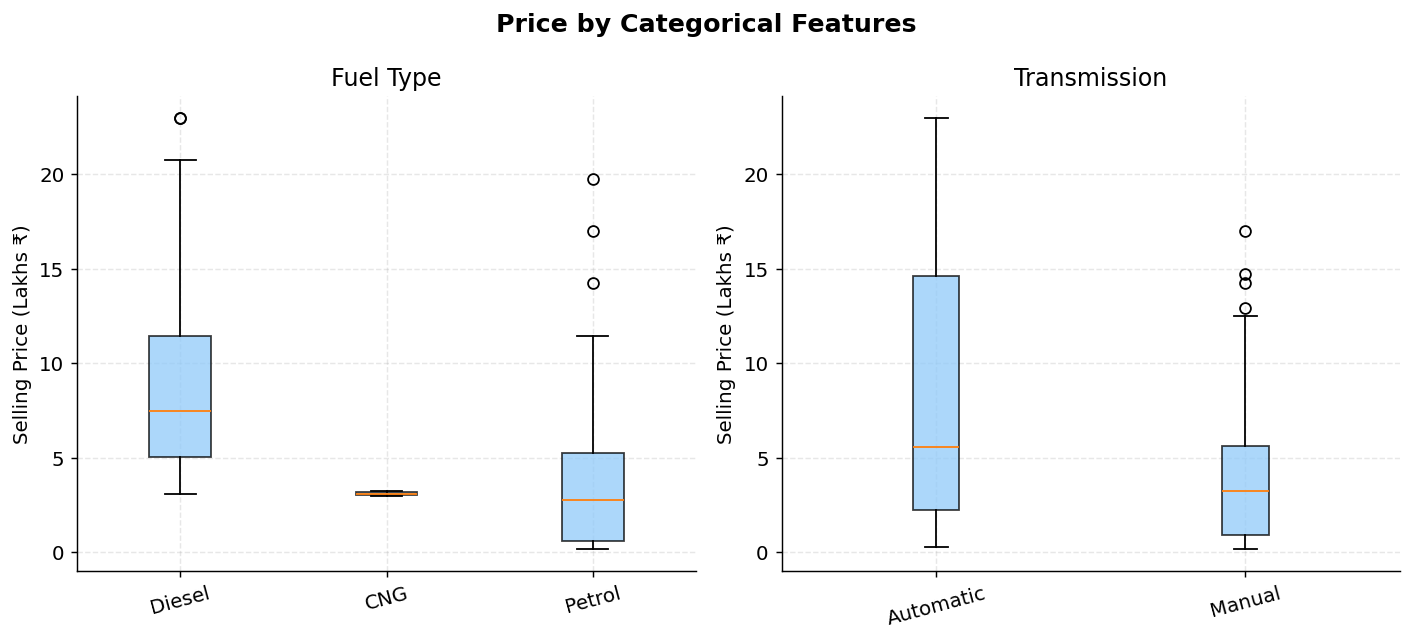

✅ Saved → /content/car_price_plots/fig3_categorical_vs_price.png


In [9]:
cat_features = [c for c in ["Fuel_Type","Seller_Type","Transmission"] if c in df.columns]
fig, axes    = plt.subplots(1, len(cat_features), figsize=(5*len(cat_features)+1, 5))
fig.suptitle("Price by Categorical Features", fontsize=14, fontweight="bold")
if len(cat_features) == 1: axes = [axes]

for ax, col in zip(axes, cat_features):
    order = df.groupby(col)[TARGET].median().sort_values(ascending=False).index
    data  = [df[df[col]==c][TARGET].values for c in order]
    bp    = ax.boxplot(data, labels=order, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("#90CAF9"); patch.set_alpha(0.75)
    ax.set_ylabel("Selling Price (Lakhs ₹)")
    ax.set_title(col.replace("_"," "))
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
SAVE3 = f"{SAVE_DIR}/fig3_categorical_vs_price.png"
plt.savefig(SAVE3, bbox_inches="tight"); plt.show()
print(f"✅ Saved → {SAVE3}")


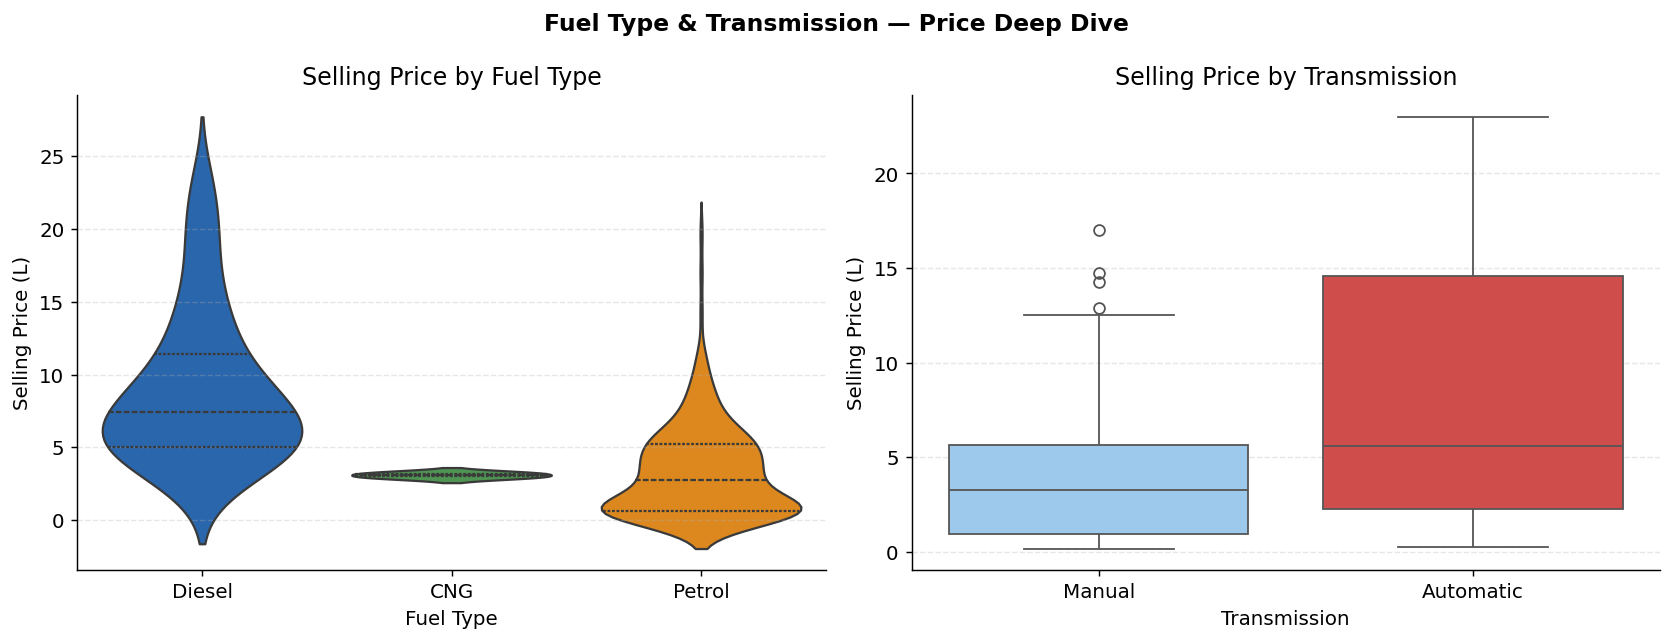

✅ Saved → /content/car_price_plots/fig4_violin_plots.png


In [10]:
# Violin plot: Fuel Type  vs  Price
if "Fuel_Type" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Fuel Type & Transmission — Price Deep Dive", fontsize=13, fontweight="bold")

    fuel_palette = {"Petrol":"#FB8C00","Diesel":"#1565C0","CNG":"#43A047",
                    "LPG":"#E53935","Electric":"#7B1FA2"}
    fuel_order = df.groupby("Fuel_Type")[TARGET].median().sort_values(ascending=False).index

    sns.violinplot(data=df, x="Fuel_Type", y=TARGET, order=fuel_order,
                   palette=fuel_palette, ax=axes[0], inner="quartile")
    axes[0].set_title("Selling Price by Fuel Type")
    axes[0].set_xlabel("Fuel Type"); axes[0].set_ylabel("Selling Price (L)")

    if "Transmission" in df.columns:
        sns.boxplot(data=df, x="Transmission", y=TARGET,
                    palette={"Manual":"#90CAF9","Automatic":"#E53935"},
                    ax=axes[1])
        axes[1].set_title("Selling Price by Transmission")
        axes[1].set_xlabel("Transmission"); axes[1].set_ylabel("Selling Price (L)")

    plt.tight_layout()
    SAVE4 = f"{SAVE_DIR}/fig4_violin_plots.png"
    plt.savefig(SAVE4, bbox_inches="tight"); plt.show()
    print(f"✅ Saved → {SAVE4}")


## 9.  Correlation Heatmap

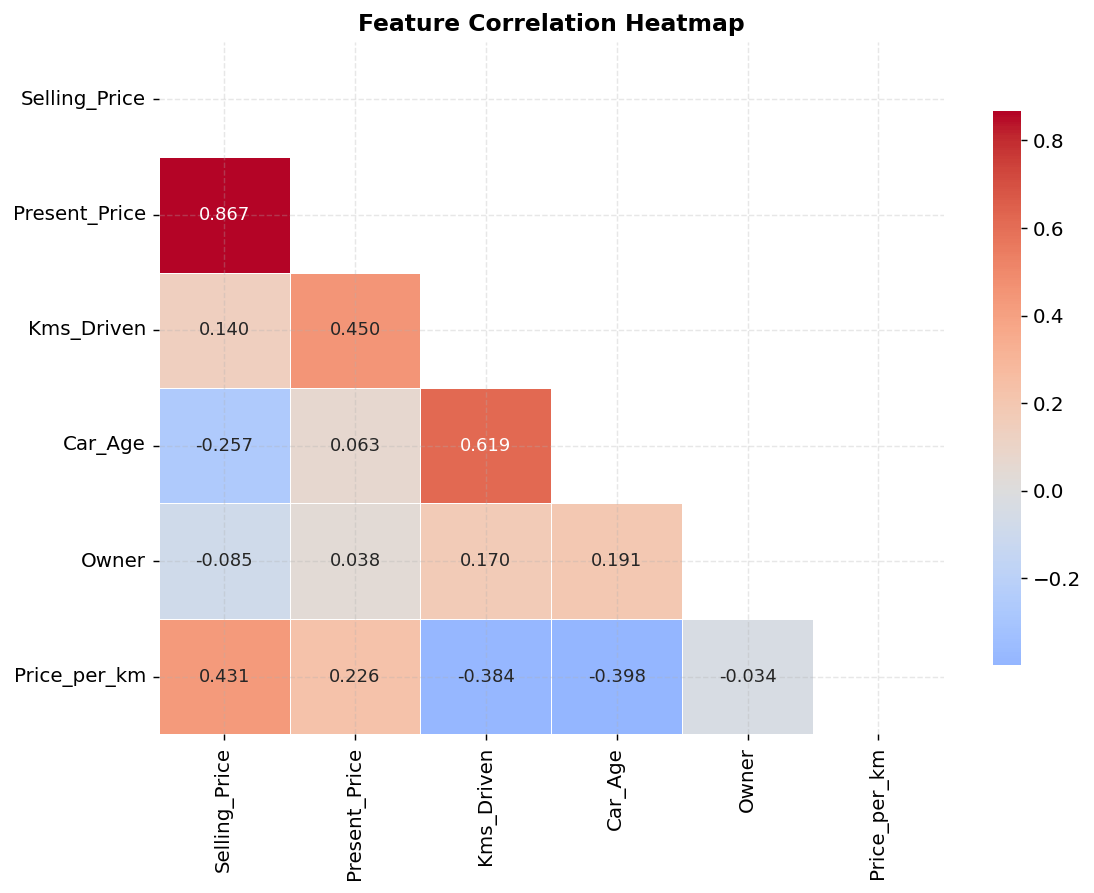

✅ Saved → /content/car_price_plots/fig5_correlation_heatmap.png

Correlation with Selling Price:
Selling_Price    1.000000
Present_Price    0.866886
Price_per_km     0.431439
Kms_Driven       0.140184
Owner           -0.085379
Car_Age         -0.256743


In [11]:
num_cols = [c for c in ["Selling_Price","Present_Price","Kms_Driven",
                         "Car_Age","Owner","Price_per_km"] if c in df.columns]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".3f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={"shrink":0.8}, annot_kws={"size":10})
ax.set_title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
SAVE5 = f"{SAVE_DIR}/fig5_correlation_heatmap.png"
plt.savefig(SAVE5, bbox_inches="tight"); plt.show()
print(f"✅ Saved → {SAVE5}")

print("\nCorrelation with Selling Price:")
print(corr["Selling_Price"].sort_values(ascending=False).to_string())


## 10.  Preprocessing & Train/Test Split

In [12]:
df_model = df.copy()

# Drop non-model columns
drop_cols = [c for c in ["Car_Name","Brand","Year","Price_per_km"] if c in df_model.columns]
df_model.drop(columns=drop_cols, inplace=True)

# Encode categoricals
cat_cols = df_model.select_dtypes(include="object").columns.tolist()
le_dict  = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col]  = le

# Fill any remaining NaNs with median
df_model.fillna(df_model.median(), inplace=True)

X = df_model.drop(columns=TARGET)
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"✅ Preprocessing complete!")
print(f"   Train samples : {X_train.shape[0]}")
print(f"   Test samples  : {X_test.shape[0]}")
print(f"   Features used : {X.shape[1]}")
print(f"   Encoded cols  : {cat_cols}")
print(f"   Feature names : {list(X.columns)}")


✅ Preprocessing complete!
   Train samples : 232
   Test samples  : 58
   Features used : 8
   Encoded cols  : ['Fuel_Type', 'selling_type', 'Transmission', 'Brand_Tier']
   Feature names : ['Present_Price', 'Kms_Driven', 'Fuel_Type', 'selling_type', 'Transmission', 'Owner', 'Car_Age', 'Brand_Tier']


## 11.  Train & Compare 6 Models

In [13]:
models = {
    "Linear Regression"  : LinearRegression(),
    "Ridge Regression"   : Ridge(alpha=1.0),
    "Lasso Regression"   : Lasso(alpha=0.1),
    "Decision Tree"      : DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest"      : RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting"  : GradientBoostingRegressor(n_estimators=200,
                                                      learning_rate=0.08,
                                                      max_depth=4, random_state=42),
}

results = {}
print(f"{'Model':<22} {'R²':>8} {'MAE (L)':>9} {'RMSE (L)':>10} {'CV R²':>10}")
print("-" * 65)

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    r2     = r2_score(y_test, y_pred)
    mae    = mean_absolute_error(y_test, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    cv_r2  = cross_val_score(model, scaler.fit_transform(X), y,
                              cv=5, scoring="r2").mean()
    results[name] = {"model":model,"y_pred":y_pred,
                     "r2":r2,"mae":mae,"rmse":rmse,"cv_r2":cv_r2}
    star = "★" if r2 == max(r["r2"] for r in results.values()) else " "
    print(f"  {star} {name:<20} {r2:>8.4f} {mae:>9.3f} {rmse:>10.3f} {cv_r2:>10.4f}")

best_name = max(results, key=lambda k: results[k]["r2"])
best      = results[best_name]
print(f"\n  ★ Best Model: {best_name}  (R² = {best['r2']:.4f})")


Model                        R²   MAE (L)   RMSE (L)      CV R²
-----------------------------------------------------------------
  ★ Linear Regression      0.8615     1.279      1.946   -13.0286
    Ridge Regression       0.8600     1.283      1.956   -13.0782
    Lasso Regression       0.8426     1.301      2.074   -12.4552
  ★ Decision Tree          0.9288     0.889      1.395     0.0923
  ★ Random Forest          0.9290     0.776      1.393     0.2599
  ★ Gradient Boosting      0.9539     0.681      1.123     0.5182

  ★ Best Model: Gradient Boosting  (R² = 0.9539)


## 12.  Model Comparison Charts

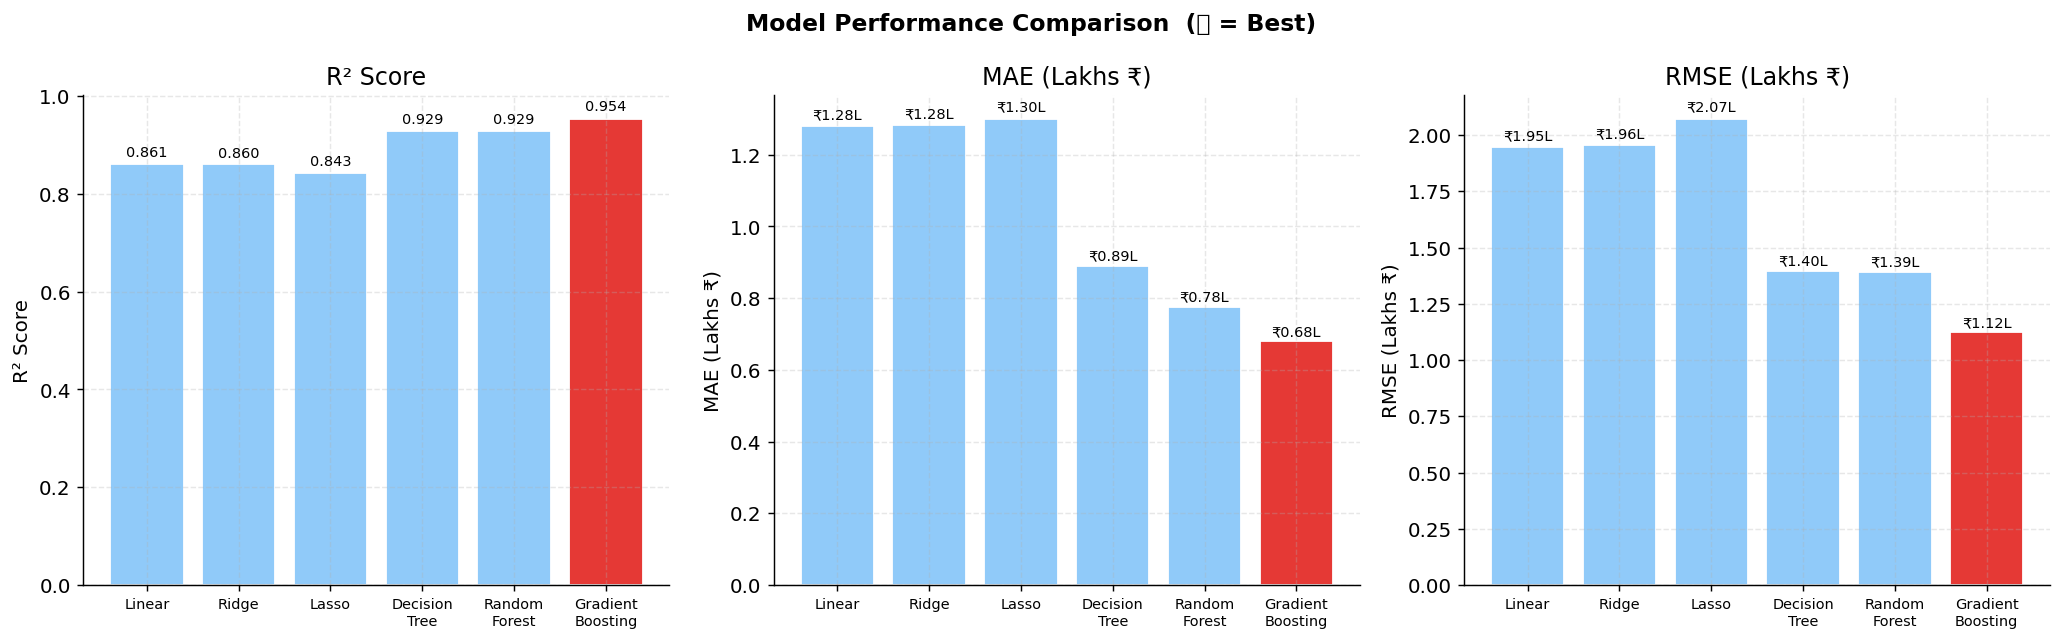

✅ Saved → /content/car_price_plots/fig6_model_comparison.png


In [14]:
names      = list(results.keys())
short      = [n.replace(" Regression","").replace(" ","\n") for n in names]
bar_colors = ["#E53935" if n==best_name else "#90CAF9" for n in names]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Performance Comparison  (🔴 = Best)", fontsize=13, fontweight="bold")

metrics = [
    ([results[n]["r2"]   for n in names], "R² Score"),
    ([results[n]["mae"]  for n in names], "MAE (Lakhs ₹)"),
    ([results[n]["rmse"] for n in names], "RMSE (Lakhs ₹)"),
]

for ax, (vals, label) in zip(axes, metrics):
    bars = ax.bar(short, vals, color=bar_colors, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f"{v:.3f}" if "R²" in label else f"₹{v:.2f}L",
                ha="center", va="bottom", fontsize=8)
    ax.set_title(label); ax.set_ylabel(label)
    ax.tick_params(axis="x", labelsize=8)

plt.tight_layout()
SAVE6 = f"{SAVE_DIR}/fig6_model_comparison.png"
plt.savefig(SAVE6, bbox_inches="tight"); plt.show()
print(f"✅ Saved → {SAVE6}")


## 13.  Actual vs Predicted & Residual Analysis

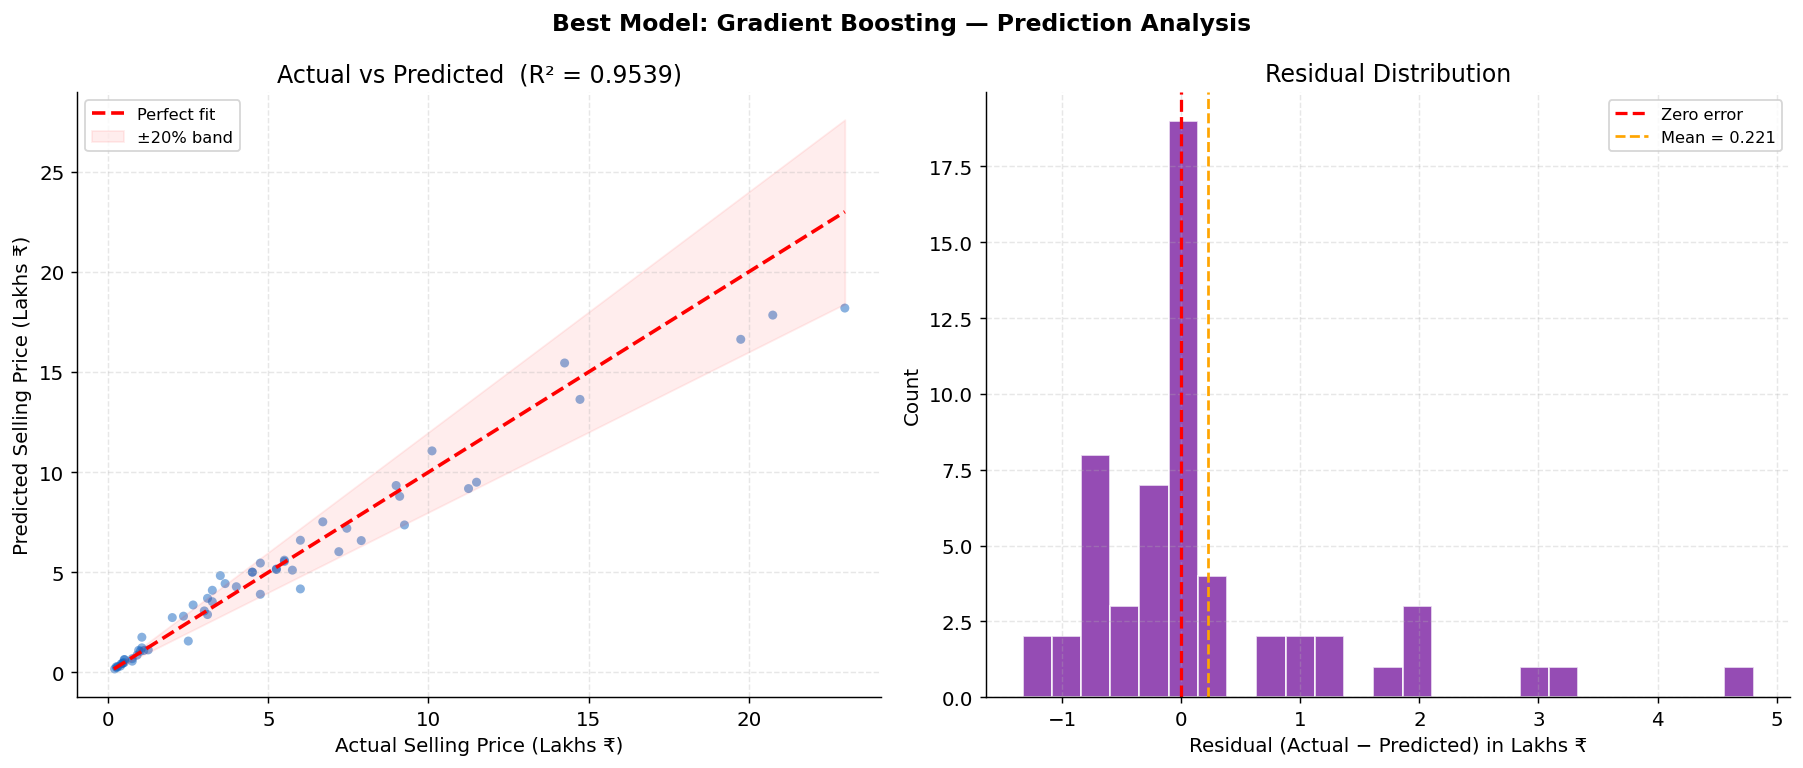

✅ Saved → /content/car_price_plots/fig7_actual_vs_predicted.png

   MAE  : ₹0.681 Lakhs
   RMSE : ₹1.123 Lakhs
   Mean Residual : 0.2211  (closer to 0 = less bias)


In [15]:
y_pred_best = best["y_pred"]
residuals   = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Best Model: {best_name} — Prediction Analysis",
             fontsize=13, fontweight="bold")

# Actual vs Predicted
ax1 = axes[0]
mn, mx = min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())
ax1.scatter(y_test, y_pred_best, alpha=0.5, s=25,
            color="#1565C0", edgecolors="none")
ax1.plot([mn,mx],[mn,mx], "r--", linewidth=2, label="Perfect fit")
ax1.fill_between([mn,mx],[mn*0.8,mx*0.8],[mn*1.2,mx*1.2],
                 alpha=0.07, color="red", label="±20% band")
ax1.set_xlabel("Actual Selling Price (Lakhs ₹)")
ax1.set_ylabel("Predicted Selling Price (Lakhs ₹)")
ax1.set_title(f"Actual vs Predicted  (R² = {best['r2']:.4f})")
ax1.legend(fontsize=9)

# Residual distribution
ax2 = axes[1]
ax2.hist(residuals, bins=25, color="#7B1FA2", alpha=0.8, edgecolor="white")
ax2.axvline(0, color="red", linestyle="--", linewidth=1.8, label="Zero error")
ax2.axvline(residuals.mean(), color="orange", linestyle="--", linewidth=1.5,
            label=f"Mean = {residuals.mean():.3f}")
ax2.set_xlabel("Residual (Actual − Predicted) in Lakhs ₹")
ax2.set_ylabel("Count"); ax2.set_title("Residual Distribution")
ax2.legend(fontsize=9)

plt.tight_layout()
SAVE7 = f"{SAVE_DIR}/fig7_actual_vs_predicted.png"
plt.savefig(SAVE7, bbox_inches="tight"); plt.show()
print(f"✅ Saved → {SAVE7}")
print(f"\n   MAE  : ₹{best['mae']:.3f} Lakhs")
print(f"   RMSE : ₹{best['rmse']:.3f} Lakhs")
print(f"   Mean Residual : {residuals.mean():.4f}  (closer to 0 = less bias)")


## 14.  Feature Importance (Random Forest)



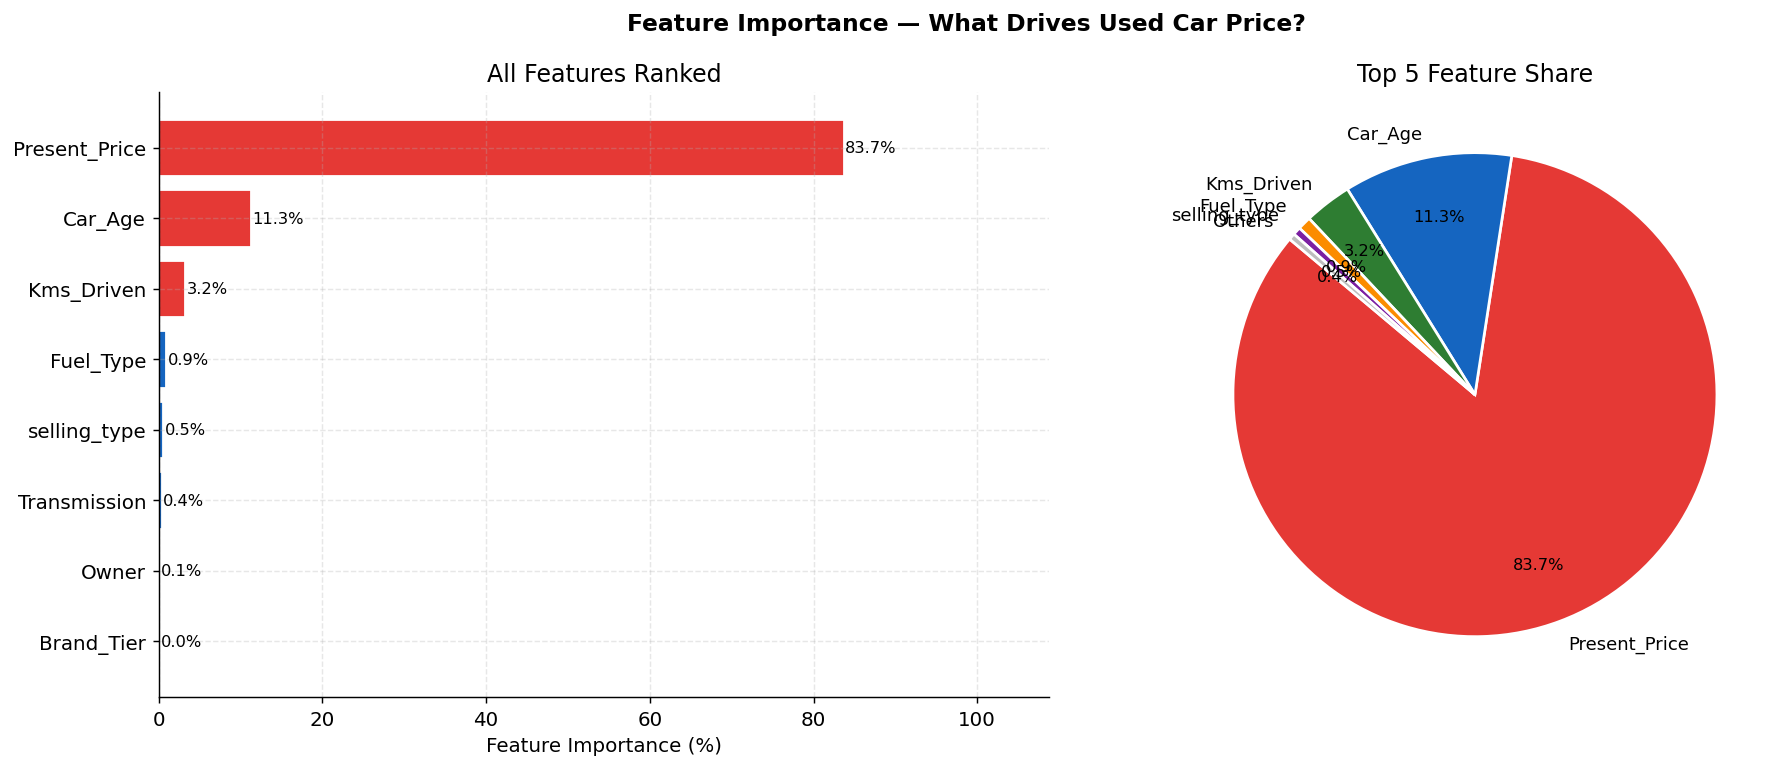

✅ Saved → /content/car_price_plots/fig8_feature_importance.png

Top Features:
  Present_Price         83.7%  ███████████████████████████████████████████████████████████████████████████████████
  Car_Age               11.3%  ███████████
  Kms_Driven            3.2%  ███
  Fuel_Type             0.9%  
  selling_type          0.5%  


In [16]:
rf_model = results["Random Forest"]["model"]
feat_imp = pd.Series(rf_model.feature_importances_,
                     index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Feature Importance — What Drives Used Car Price?",
             fontsize=13, fontweight="bold")

# Horizontal bar
colors_imp = ["#E53935" if i<3 else "#1565C0" if i<6 else "#90CAF9"
              for i in range(len(feat_imp))]
axes[0].barh(feat_imp.index[::-1], feat_imp.values[::-1]*100,
             color=colors_imp[::-1], edgecolor="white")
for i, (idx, val) in enumerate(zip(feat_imp.index[::-1], feat_imp.values[::-1])):
    axes[0].text(val*100+0.2, i, f"{val*100:.1f}%", va="center", fontsize=9)
axes[0].set_xlabel("Feature Importance (%)")
axes[0].set_title("All Features Ranked")
axes[0].set_xlim(0, feat_imp.values.max()*130)

# Pie chart — top features
top5       = feat_imp.head(5)
other_sum  = feat_imp.iloc[5:].sum()
pie_vals   = list(top5.values) + [other_sum]
pie_labels = list(top5.index)  + ["Others"]
pie_colors = ["#E53935","#1565C0","#2E7D32","#FB8C00","#7B1FA2","#BDBDBD"]
wedges, texts, autotexts = axes[1].pie(
    pie_vals, labels=pie_labels, colors=pie_colors,
    autopct="%1.1f%%", startangle=140, pctdistance=0.75,
    wedgeprops={"edgecolor":"white","linewidth":1.5})
for t in texts:     t.set_fontsize(10)
for t in autotexts: t.set_fontsize(9)
axes[1].set_title("Top 5 Feature Share")

plt.tight_layout()
SAVE8 = f"{SAVE_DIR}/fig8_feature_importance.png"
plt.savefig(SAVE8, bbox_inches="tight"); plt.show()
print(f"✅ Saved → {SAVE8}")
print("\nTop Features:")
for feat, imp in feat_imp.head(5).items():
    bar = "█" * int(imp * 100)
    print(f"  {feat:<20}  {imp*100:.1f}%  {bar}")


## 15.  Predict Price for a New Car
Fill in the car details below to get a predicted selling price!


In [17]:
def predict_selling_price(car_dict: dict) -> float:
    sample = pd.DataFrame([car_dict])
    # Add engineered features
    if "Year" in car_dict:
        sample["Car_Age"] = CURRENT_YEAR - car_dict["Year"]
    # Encode categoricals using saved encoders
    for col, le in le_dict.items():
        if col in sample.columns:
            try:
                sample[col] = le.transform(sample[col].astype(str))
            except ValueError:
                sample[col] = 0   # unknown category → 0
    # Fill missing features with median
    for col in X.columns:
        if col not in sample.columns:
            sample[col] = X[col].median()
    sample   = sample[X.columns].fillna(X.median())
    scaled   = scaler.transform(sample)
    return best["model"].predict(scaled)[0]

# ── Sample cars to predict ──────────────────────────────────────────────
sample_cars = [
    {"label":"Maruti Swift (2019, Petrol, Dealer)",
     "Year":2019,"Present_Price":5.59,"Kms_Driven":25000,
     "Fuel_Type":"Petrol","Seller_Type":"Dealer","Transmission":"Manual","Owner":0},
    {"label":"Honda City (2017, Diesel, Individual)",
     "Year":2017,"Present_Price":11.60,"Kms_Driven":45000,
     "Fuel_Type":"Diesel","Seller_Type":"Individual","Transmission":"Manual","Owner":1},
    {"label":"Toyota Innova (2015, Diesel, Dealer)",
     "Year":2015,"Present_Price":17.26,"Kms_Driven":78000,
     "Fuel_Type":"Diesel","Seller_Type":"Dealer","Transmission":"Manual","Owner":1},
    {"label":"Hyundai Creta (2021, Automatic)",
     "Year":2021,"Present_Price":14.50,"Kms_Driven":18000,
     "Fuel_Type":"Petrol","Seller_Type":"Dealer","Transmission":"Automatic","Owner":0},
]

print("=" * 58)
print("  🚗 CAR PRICE PREDICTIONS")
print("=" * 58)
for car in sample_cars:
    label = car.pop("label")
    price = predict_selling_price(car)
    print(f"  {label}")
    print(f"  → Predicted Selling Price: ₹ {price:.2f} Lakhs")
    print()


  🚗 CAR PRICE PREDICTIONS
  Maruti Swift (2019, Petrol, Dealer)
  → Predicted Selling Price: ₹ 3.70 Lakhs

  Honda City (2017, Diesel, Individual)
  → Predicted Selling Price: ₹ 9.02 Lakhs

  Toyota Innova (2015, Diesel, Dealer)
  → Predicted Selling Price: ₹ 11.41 Lakhs

  Hyundai Creta (2021, Automatic)
  → Predicted Selling Price: ₹ 12.58 Lakhs



## 16.  Key Insights & Download All Plots

In [18]:
print("=" * 62)
print("  KEY INSIGHTS — Car Price Prediction")
print("=" * 62)
print(f"\n  🏆 Best Model : {best_name}")
print(f"  📈 R² Score   : {best['r2']:.4f}  ({best['r2']*100:.1f}% variance explained)")
print(f"  📉 MAE        : ₹{best['mae']:.3f} Lakhs  (avg prediction error)")
print(f"  📉 RMSE       : ₹{best['rmse']:.3f} Lakhs")
print(f"\n  🔑 Top Price Drivers:")
for feat, imp in feat_imp.head(4).items():
    print(f"    • {feat:<20}  {imp*100:.1f}% importance")
print(f"\n  💼 Business Insights:")
print("  1. Present_Price is the strongest predictor — higher new price = higher resale")
print("  2. Newer cars (lower Car_Age) command significantly higher prices")
print("  3. Diesel cars fetch higher prices than Petrol in the used market")
print("  4. Dealer-sold cars are priced higher than individual sellers")
print("  5. Automatic transmission adds a premium over Manual")
print("  6. More owners → lower selling price (depreciation effect)")
print("=" * 62)


  KEY INSIGHTS — Car Price Prediction

  🏆 Best Model : Gradient Boosting
  📈 R² Score   : 0.9539  (95.4% variance explained)
  📉 MAE        : ₹0.681 Lakhs  (avg prediction error)
  📉 RMSE       : ₹1.123 Lakhs

  🔑 Top Price Drivers:
    • Present_Price         83.7% importance
    • Car_Age               11.3% importance
    • Kms_Driven            3.2% importance
    • Fuel_Type             0.9% importance

  💼 Business Insights:
  1. Present_Price is the strongest predictor — higher new price = higher resale
  2. Newer cars (lower Car_Age) command significantly higher prices
  3. Diesel cars fetch higher prices than Petrol in the used market
  4. Dealer-sold cars are priced higher than individual sellers
  5. Automatic transmission adds a premium over Manual
  6. More owners → lower selling price (depreciation effect)
